## Implementing Simple Chatbot using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

# Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

c:\Users\mani2\Documents\RAG-Mastery\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_9894c391cd', 'id': 'chatcmpl-DRdoJMJZWDvpCPqql9ddcBnoefj0a', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d62de-be54-7760-bb11-7cc6cc5e41db-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_groq import ChatGroq
# llm_groq=ChatGroq(model="qwen-qwq-32b") 
llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Mani and i like to play cricket")

AIMessage(content="<think>\nOkay, the user is Mani and he likes to play cricket. Let me see how to respond.\n\nFirst, I should acknowledge his introduction. Maybe say hello and be friendly.\n\nHe mentioned he likes cricket, so I can ask about his role in the game. Do he play as a batsman, bowler, or fielder? That shows interest in his hobby.\n\nAlso, maybe ask if he plays regularly or is into watching matches. It helps to get a conversation going.\n\nI should keep the tone positive and enthusiastic. Maybe add an emoji to make it friendly.\n\nCheck if there's anything else to add. Oh, perhaps ask about his favorite team or player? But maybe start with the basics first.\n\nMake sure the questions are open-ended to encourage him to talk more. Let me put it all together in a natural way.\n</think>\n\nHello Mani! 🏏 That's awesome—cricket is such a thrilling sport! I'd love to know more about your passion. Do you play professionally, or just for fun with friends? What position do you usually

#### We will start with creating Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

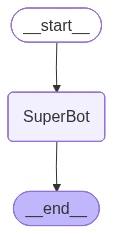

In [7]:
graph=StateGraph(State)

# Node
graph.add_node("SuperBot",superbot)

# Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder=graph.compile(checkpointer=memory)

# Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
# Invocation
config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='fc65f67f-03b7-4f6b-8240-0247144a3602'),
  AIMessage(content='<think>\nOkay, the user is Krish and he mentioned he likes cricket. Let me start by acknowledging his introduction. I should respond in a friendly and welcoming manner.\n\nFirst, I need to greet him. Maybe say something like "Hi Krish!" to acknowledge his name. Then, mention his interest in cricket. I should ask a follow-up question to keep the conversation going. Maybe ask about his favorite team or if he plays. But I need to keep it open-ended so he can elaborate.\n\nI should also consider possible follow-up interactions. If he mentions a team, I can ask about recent matches or players. If he says he plays, I can ask about his favorite role in the game, like batting or bowling. It\'s good to have a few options ready.\n\nI need to make sure the response is positive and encourages him to share more. Avo

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

![alt text](download-2.png)


#### Streaming the responses with Stream method

In [9]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Mani And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Mani and mentioned he likes cricket. I need to respond in a friendly and engaging way. Since he's new, maybe start by welcoming him and showing interest in his hobby. I should ask him some questions to keep the conversation going, maybe about his favorite teams or players. Let me make sure the tone is positive and encouraging so he feels comfortable to talk more.\n</think>\n\nHi Mani! Nice to meet you! 🏏 I love that you're a cricket fan—what's your favorite part about the game? Do you have a favorite team or player you follow? Let me know if you'd like to chat more about matches, strategies, or even some fun cricket trivia! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 19, 'total_tokens': 170, 'completion_time': 0.317893082, 'completion_tokens_details': None, 'prompt_time': 0.00098142, 'prompt_tokens_details': None, 'queue_time': 0.196805

In [10]:
for chunk in graph_builder.stream({
    'messages':"I also like football"},
    config,
    stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Mani And I like cricket', additional_kwargs={}, response_metadata={}, id='46bc97d3-a502-4c3d-a080-81dc8903576c'), AIMessage(content="<think>\nOkay, the user introduced himself as Mani and mentioned he likes cricket. I need to respond in a friendly and engaging way. Since he's new, maybe start by welcoming him and showing interest in his hobby. I should ask him some questions to keep the conversation going, maybe about his favorite teams or players. Let me make sure the tone is positive and encouraging so he feels comfortable to talk more.\n</think>\n\nHi Mani! Nice to meet you! 🏏 I love that you're a cricket fan—what's your favorite part about the game? Do you have a favorite team or player you follow? Let me know if you'd like to chat more about matches, strategies, or even some fun cricket trivia! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 19, 'total_tokens': 170, 'completio

In [11]:
for chunk in graph_builder.stream({
    'messages':"I also like football "},
    config,
    stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, let me start by looking at the conversation so far. The user, Mani, has mentioned liking both cricket and football. The assistant has already asked about favorite teams, leagues, and formats for both sports. Now, Mani says again, "I also like football," which is a repetition. \n\nHmm, maybe Mani is emphasizing that football is another favorite, but since the assistant already knows that, perhaps there\'s a need to elaborate more. The assistant should acknowledge the repetition but also invite more specific details to keep the conversation engaging.\n\nWait, in the previous response, the assistant asked if football is equally fun as cricket and about specific teams or leagues. Mani might be responding again to elaborate. Since the user repeated "I also like football," maybe they want to expand on their football preferences. Let me check the history again.\n\nOriginal user message after the first football mention: the assistant

In [12]:
for chunk in graph_builder.stream({
    'messages':"I Love sports "},
    config,
    stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Mani And I like cricket', additional_kwargs={}, response_metadata={}, id='46bc97d3-a502-4c3d-a080-81dc8903576c'), AIMessage(content="<think>\nOkay, the user introduced himself as Mani and mentioned he likes cricket. I need to respond in a friendly and engaging way. Since he's new, maybe start by welcoming him and showing interest in his hobby. I should ask him some questions to keep the conversation going, maybe about his favorite teams or players. Let me make sure the tone is positive and encouraging so he feels comfortable to talk more.\n</think>\n\nHi Mani! Nice to meet you! 🏏 I love that you're a cricket fan—what's your favorite part about the game? Do you have a favorite team or player you follow? Let me know if you'd like to chat more about matches, strategies, or even some fun cricket trivia! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 151, 'prompt_tokens': 19, 'total_tokens': 170, 'completio

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Contains langgraph_node, the node emitting the event.

In [14]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({
    "messages":["Hi My name is Mani and I like to play cricket"]},
    config,
    version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Mani and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019d62e2-5c35-7c60-b8d7-13721db2ec96', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Mani And I like cricket', additional_kwargs={}, response_metadata={}, id='46bc97d3-a502-4c3d-a080-81dc8903576c'), AIMessage(content="<think>\nOkay, the user introduced himself as Mani and mentioned he likes cricket. I need to respond in a friendly and engaging way. Since he's new, maybe start by welcoming him and showing interest in his hobby. I should ask him some questions to keep the conversation going, maybe about his favorite teams or players. Let me make sure the tone is positive and encouraging so he feels comfortable to talk more.\n</think>\n\nHi Mani! Nice to meet you! 🏏 I love that you're a cricket fan—what's y